<a href="https://colab.research.google.com/github/Keshav820/GIS_Lecture/blob/main/GIS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GIS Material Sources
*   [Introduction to Python for Geographic Data Analysis](https://pythongis.org/)
*   [Geospatial Data Science (by Prof. Anupam Sobti)](https://anupamsobti.github.io/geospatial-data-science-2025/)
*   [Introduction to QGIS (Full Course)](https://courses.spatialthoughts.com/introduction-to-qgis.html)





# GIS Data Sources

*   [OpenStreetMap (OSM)](https://download.geofabrik.de/)
*   [Natural Earth](https://www.naturalearthdata.com/)
*   [The Humanitarian Data Exchange](https://data.humdata.org/)
*   [Global Earthquack Model (GEM) Dataset](https://www.globalquakemodel.org/products?type=Dataset)
*   [NOAA - National Centers for Environmental Information](https://www.ngdc.noaa.gov/hazel/view/about) - Natural Hazards Data
*   [NYC OpenData](https://opendata.cityofnewyork.us/) - New York City Data
*   [Our World in Data](https://ourworldindata.org/)
*   [ECONDL](https://econdl.github.io/datasets.html)
*   [SHRUG Dataset(s)](https://www.devdatalab.org/shrug_download/)
*   [IMPUS Dataset](https://www.ipums.org/)
    *   [IMPUS - NHGIS](https://www.nhgis.org/)
    *   [IMPUS - IHGIS](https://ihgis.ipums.org/)









# Plotting GIS Maps

In [ ]:
import pandas as pd
import geopandas as gpd
from zipfile import ZipFile
import matplotlib.pyplot as plt
from google.colab import files
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiPolygon

['DISTRICT_BOUNDARY.CPG', 'DISTRICT_BOUNDARY.dbf', 'DISTRICT_BOUNDARY.prj', 'DISTRICT_BOUNDARY.shp', 'DISTRICT_BOUNDARY.shx']


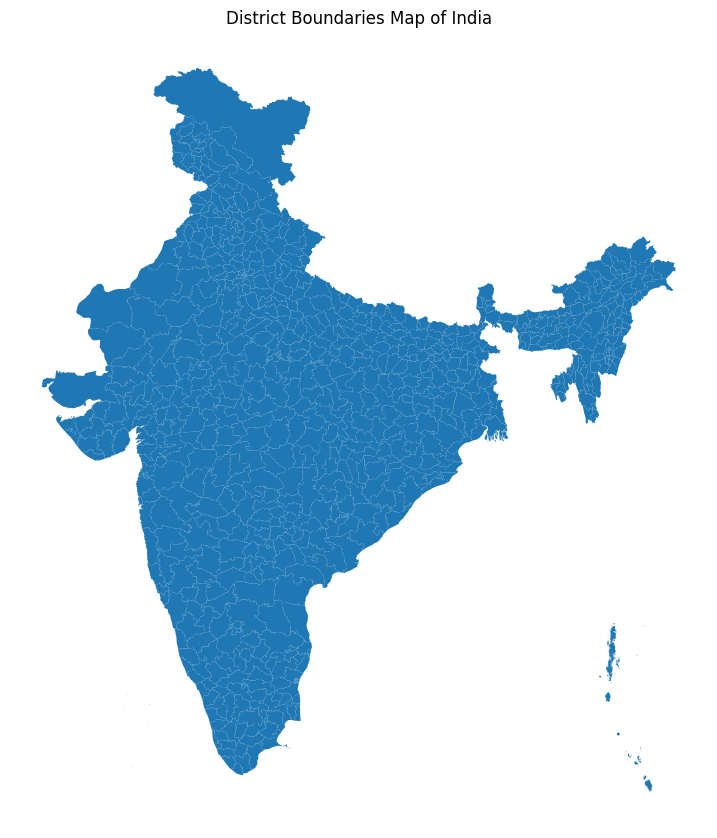

In [ ]:
# District Shapefile || Source: Github / Survey of India - Digital Products
data = "/content/archive.zip"

# Getting names from the ZipFile
with ZipFile(data) as d:
  print(d.namelist())

# Opening the District Boundary Dataset
gdf = gpd.read_file("/content/archive.zip!DISTRICT_BOUNDARY.shp")
# print(gdf)

# Plotting the Districts Boundaries Map of India
fig, ax1 = plt.subplots()
gdf.plot(ax=ax1)
fig.set_size_inches(9, 12, forward=True)
plt.title("District Boundaries Map of India")
plt.axis("Off")
plt.show()

In [ ]:
gdf.head()

,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry
0,MORBI,GUJAR>T,None,24,673,539476.764723,4.791280e+09,"POLYGON ((3108952.09 3942577.01, 3109009.987 3..."
1,AHMAD>B>D,GUJAR>T,None,24,438,857254.094647,6.966374e+09,"POLYGON ((3193648.356 3920619.089, 3193646.392..."
2,>NAND,GUJAR>T,None,24,440,393046.690523,3.054307e+09,"POLYGON ((3297696.184 3879979.348, 3297775.311..."
3,DEVBHUMI DW>RKA,GUJAR>T,None,24,674,661732.986530,4.002784e+09,"MULTIPOLYGON (((2924145.687 3865429.524, 29241..."
4,J>MNAGAR,GUJAR>T,None,24,447,737428.071884,5.694271e+09,"MULTIPOLYGON (((3044918.968 3859136.847, 30448..."


In [ ]:
# Cleaning the column names of Districts and States
cols_to_clean = ["District", "STATE"]

# Replacing the unwanted characters
replace = {">": "A", "@": "U", "|": "i"}

for col in cols_to_clean:
  gdf[col] = gdf[col].astype(str)
  for old, new in replace.items():
    gdf[col] = gdf[col].str.replace(old, new, regex=False)

gdf["District"] = gdf["District"].str.capitalize()#.lower()
gdf["STATE"] = gdf["STATE"].str.capitalize()#.lower()

# Printing first five rows of the dataset
print(gdf.shape)
gdf.head(20)

(742, 8)


,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry
0,Morbi,Gujarat,None,24,673,5.394768e+05,4.791280e+09,"POLYGON ((3108952.09 3942577.01, 3109009.987 3..."
1,Ahmadabad,Gujarat,None,24,438,8.572541e+05,6.966374e+09,"POLYGON ((3193648.356 3920619.089, 3193646.392..."
2,Anand,Gujarat,None,24,440,3.930467e+05,3.054307e+09,"POLYGON ((3297696.184 3879979.348, 3297775.311..."
3,Devbhumi dwarka,Gujarat,None,24,674,6.617330e+05,4.002784e+09,"MULTIPOLYGON (((2924145.687 3865429.524, 29241..."
4,Jamnagar,Gujarat,None,24,447,7.374281e+05,5.694271e+09,"MULTIPOLYGON (((3044918.968 3859136.847, 30448..."
5,Kachchh,Gujarat,None,24,449,2.097007e+06,3.913165e+10,"MULTIPOLYGON (((3022570.473 3944081.402, 30225..."
6,Bhavnagar,Gujarat,None,24,443,5.050122e+05,6.514338e+09,"MULTIPOLYGON (((3224033.34 3759508.682, 322398..."
7,Bharuch,Gujarat,None,24,442,8.025799e+05,4.745943e+09,"MULTIPOLYGON (((3265674.825 3764366.597, 32657..."
8,Surat,Gujarat,None,24,459,5.230863e+05,4.175888e+09,"POLYGON ((3295065.918 3752923.858, 3295235.115..."
9,Navsari,Gujarat,None,24,453,3.275102e+05,2.126084e+09,"POLYGON ((3266101.911 3699818.493, 3266295.418..."


In [ ]:
# Selecting the columns to make an excel file (used for IHCI Treated Districts)
columns_needed = ["District", "STATE", "REMARKS", "State_LGD", "DISTRICT_L"]
df_selected = gdf[columns_needed]

# Export to Excel
output_excel = r"district_code_shape_file.xlsx"
df_selected.to_excel(output_excel, index=False)

# Downloading the Excel File
# files.download("district_code_shape_file.xlsx")

['gis_osm_railways_nz.cpg', 'gis_osm_railways_nz.dbf', 'gis_osm_railways_nz.prj', 'gis_osm_railways_nz.shp', 'gis_osm_railways_nz.shx']


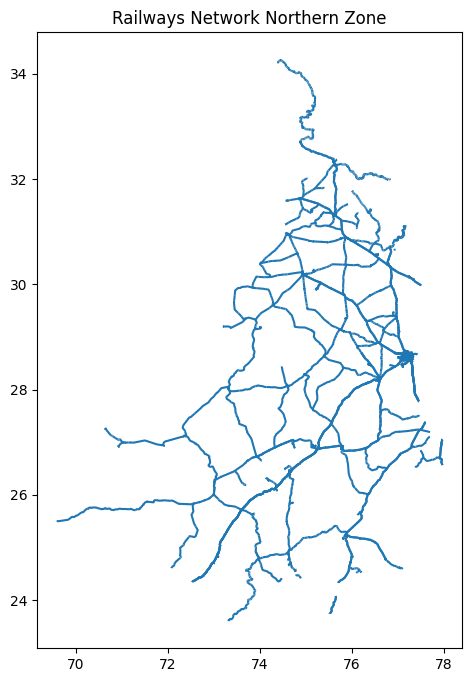

,osm_id,code,fclass,name,layer,bridge,tunnel,geometry
0,16571243,6101,rail,None,0,F,F,"LINESTRING (75.63886 31.3038, 75.64258 31.3019..."
1,23785565,6101,rail,None,0,F,F,"LINESTRING (75.91076 31.52661, 75.90876 31.525..."
2,24530429,6103,subway,Delhi Metro Yellow Line,1,T,F,"LINESTRING (77.06826 28.45438, 77.06883 28.455..."
3,24690209,6103,subway,Delhi Metro Red Line,0,F,F,"LINESTRING (77.25397 28.66729, 77.25336 28.667..."
4,28013592,6101,rail,None,0,F,F,"LINESTRING (75.79205 30.99807, 75.79159 30.999..."


In [ ]:
# Filepath for Railways Northern Zone || Source: OpenStreetMap (OSM)
railways_northern_zone = "/content/Railways_Northern_Zone.zip"

# File inside the Railways Northern Zone zipfile
with ZipFile(railways_northern_zone) as rnz:
  print(rnz.namelist())

# Getting data of railways northern zone
gdf_rnz = gpd.read_file("/content/Railways_Northern_Zone.zip!gis_osm_railways_nz.shp")
# print(gdf_rnz.head())

# Plotting the Railways Map
fig, ax2 = plt.subplots()
gdf_rnz.plot(ax=ax2)
fig.set_size_inches(8,8)
plt.title("Railways Network Northern Zone")
plt.show()

# Printing first five rows of the Indian - Northern Railways Network GIS dataset
gdf_rnz.head()

PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
EPSG:4326
False


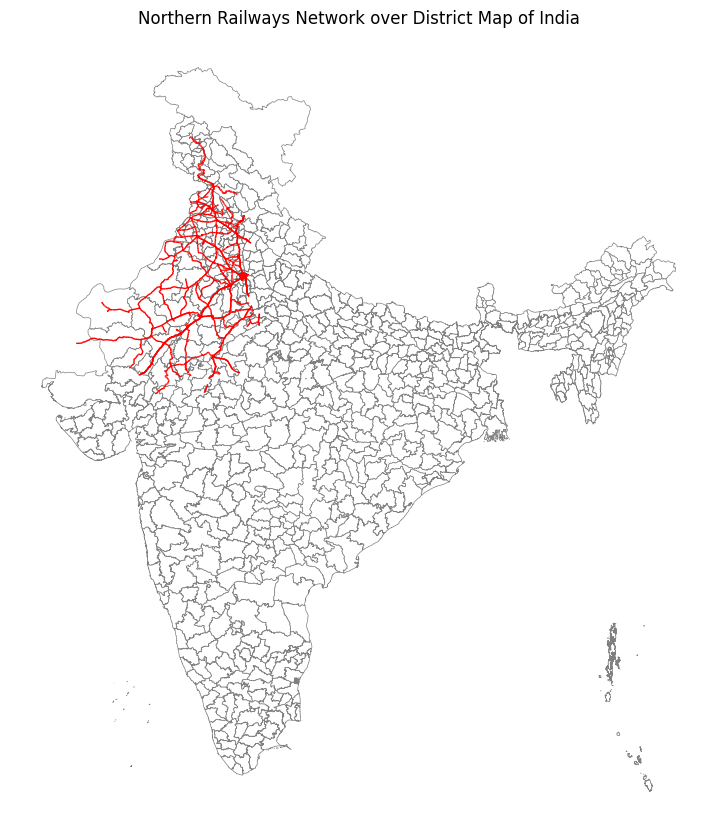

In [ ]:
# Checking the datatypes of gdf (India Districts shapefile) and gdf_rnz (Inidan Northern Railways)
print(gdf.crs)
print(gdf_rnz.crs)

# Checking if the both the datasets have same units (Degree (lat-lon) or, Distance (metres))
print(gdf.crs == gdf_rnz.crs)

# Converting the one datasets to the same unit
gdf_rnz = gdf_rnz.to_crs(gdf.crs) # Can be used if the datasets are not in the same units

# Plotting the Figure
fig, ax = plt.subplots(figsize=(9, 12))

# Plot districts (base layer)
gdf.plot(ax=ax, color="white", edgecolor="grey", linewidth=0.5)

# Plot railways (overlay)
gdf_rnz.plot(ax=ax, color="red", linewidth=1)

plt.title("Northern Railways Network over District Map of India")
plt.axis("off")
plt.show()

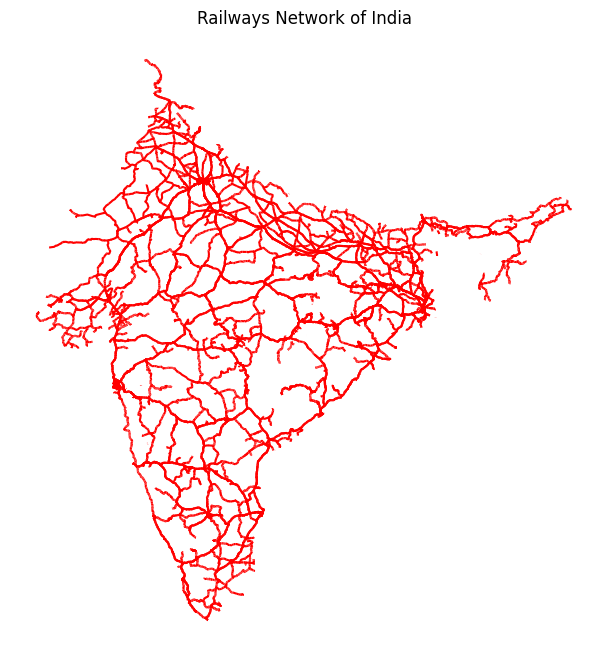

,osm_id,code,fclass,name,layer,bridge,tunnel,geometry
0,16571243,6101,rail,None,0,F,F,"LINESTRING (75.63886 31.3038, 75.64258 31.3019..."
1,23785565,6101,rail,None,0,F,F,"LINESTRING (75.91076 31.52661, 75.90876 31.525..."
2,24530429,6103,subway,Delhi Metro Yellow Line,1,T,F,"LINESTRING (77.06826 28.45438, 77.06883 28.455..."
3,24690209,6103,subway,Delhi Metro Red Line,0,F,F,"LINESTRING (77.25397 28.66729, 77.25336 28.667..."
4,28013592,6101,rail,None,0,F,F,"LINESTRING (75.79205 30.99807, 75.79159 30.999..."


In [ ]:
# Calling all different railway zones datasets to merge it and then plot it.
gdf_nz = gpd.read_file("/content/Railways_Northern_Zone.zip!gis_osm_railways_nz.shp")
gdf_sz = gpd.read_file("/content/Railways_Southern_Zone.zip!gis_osm_railways_sz.shp")
gdf_ez = gpd.read_file("/content/Railways_Eastern_Zone.zip!gis_osm_railways_ez.shp")
gdf_wz = gpd.read_file("/content/Railways_Western_Zone.zip!gis_osm_railways_wz.shp")
gdf_cz = gpd.read_file("/content/Railways_Central_Zone.zip!Railways_Central_Zone.zip!gis_osm_railways_cz.shp")
gdf_nez = gpd.read_file("/content/Railways_North_Eastern_Zone.zip!Railways_North_Eastern_Zone.zip!gis_osm_railways_nez.shp")

# Merging all the railway zones datasets
gdf_rn = pd.concat([gdf_nz, gdf_sz, gdf_ez, gdf_wz, gdf_cz, gdf_nez])
# print(gdf_rn.head())

# Plotting the Railway Network of India
fig, ax3 = plt.subplots()
gdf_rn.plot(ax=ax3, color="red")
fig.set_size_inches(8,8)
plt.title("Railways Network of India")
plt.axis("Off")
plt.show()

# Printing first five rows of the Indian - Northern Railways Network GIS dataset
gdf_rn.head()

EPSG:4326
PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
False


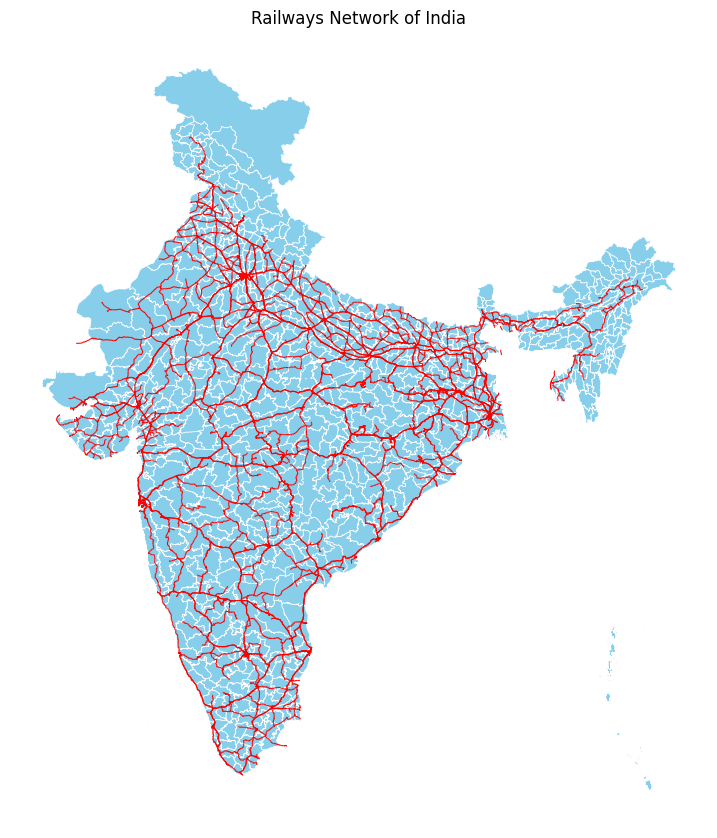

In [ ]:
## Plotting the Railways Network of India on the Administrative Map of India

# Checking the geographic datatypes of gdf (India Districts shapefile) and gdf_rn (Inidan Railways Network)
print(gdf_rn.crs)
print(gdf.crs)

# Checking if both the datatypes are same or not
print(gdf_rn.crs == gdf.crs)

# Converting the datastypes, so that both the datatypes are of same types
gdf_rn = gdf_rn.to_crs(gdf.crs)

# Plotting the Figure
fig, ax = plt.subplots(figsize=(9,12))

# Plotting the Districts Map (Base Layer)
gdf.plot(ax=ax, color="skyblue", edgecolor="white", linewidth=0.5)

# Plottign the Railways Network of India (Top Layer)
gdf_rn.plot(ax=ax, edgecolor="red", linewidth=0.75)

plt.title("Railways Network of India")
plt.axis("Off")
fig.show()

In [ ]:
# Calculating the Railways Network Length
gdf = gdf.to_crs(epsg=3857)        # Districts
gdf_rn = gdf_rn.to_crs(epsg=3857)  # Railways

# Cutting the railway lines into district pieces
rail_district = gpd.overlay(gdf_rn, gdf, how="intersection")

# Calculating the same in kilometres
rail_district["rail_km"] = rail_district.geometry.length / 1000

# Distrcit Rail Length
district_rail_length = (rail_district.groupby("District")["rail_km"].sum().reset_index())

district_rail_length.head()

,District,rail_km
0,Adilabad,79.193288
1,Agra,718.585299
2,Ahamadnagar,264.412908
3,Ahmadabad,787.375708
4,Aizawl,9.929081


In [ ]:
# Finding the total length of Indian Railways
total_rail_km = gdf_rn.geometry.length.sum() / 1000
print(f"Total Railway Length of India: {total_rail_km:.2f} km")

Total Railway Length of India: 148627.99 km


In [ ]:
# Finding the length of railways of a particular district
district_rail_length.loc[district_rail_length["District"] == "lucknow", "rail_km"]

,rail_km


In [ ]:
# State Shape File
state = "/content/archive_state.zip"

# Printing the names of the files iniside the ZipFile
with ZipFile(state) as s:
  print(s.namelist())

['Indian_States.dbf', 'Indian_States.prj', 'Indian_States.shp', 'Indian_States.shx']


Index(['st_nm', 'geometry', 'STATE'], dtype='object')


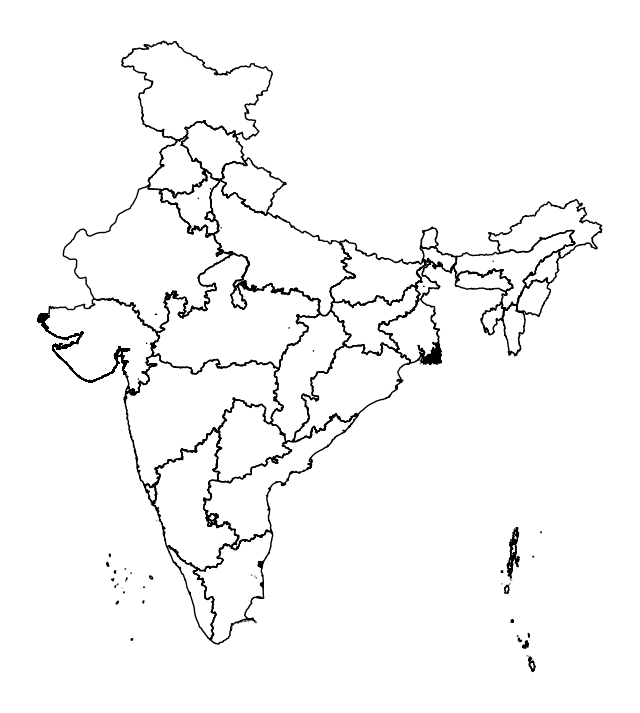

In [ ]:
# State Boundary File
gdf_st = gpd.read_file("/content/archive_state.zip!Indian_States.shp")
gdf_st["STATE"] = gdf_st["st_nm"].str.lower()
print(gdf_st.columns)
# print(gdf_st.head())

# Plotting the State Boundary
fig, ax = plt.subplots(figsize=(8,10))
gdf_st.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
plt.axis("off")
plt.show()

In [ ]:
# Merging the Districts with the Rail Length
gdf_rail = gdf.merge(district_rail_length, on="District", how="left")

gdf_rail.head()

,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry,rail_km
0,Morbi,Gujarat,None,24,673,539476.764723,4.791280e+09,"POLYGON ((7916729.974 2657739.258, 7916794.687...",354.909457
1,Ahmadabad,Gujarat,None,24,438,857254.094647,6.966374e+09,"POLYGON ((8011893.249 2638969.809, 8011890.947...",787.375708
2,Anand,Gujarat,None,24,440,393046.690523,3.054307e+09,"POLYGON ((8129232.514 2599976.4, 8129320.292 2...",266.638210
3,Devbhumi dwarka,Gujarat,None,24,674,661732.986530,4.002784e+09,"MULTIPOLYGON (((7718827.698 2557929.563, 77188...",211.011112
4,Jamnagar,Gujarat,None,24,447,737428.071884,5.694271e+09,"MULTIPOLYGON (((7852087.684 2560524.569, 78520...",313.510266


In [ ]:
gdf_rail.columns

Index(['District', 'STATE', 'REMARKS', 'State_LGD', 'DISTRICT_L', 'Shape_Leng',
       'Shape_Area', 'geometry', 'rail_km'],
      dtype='object')

False
True


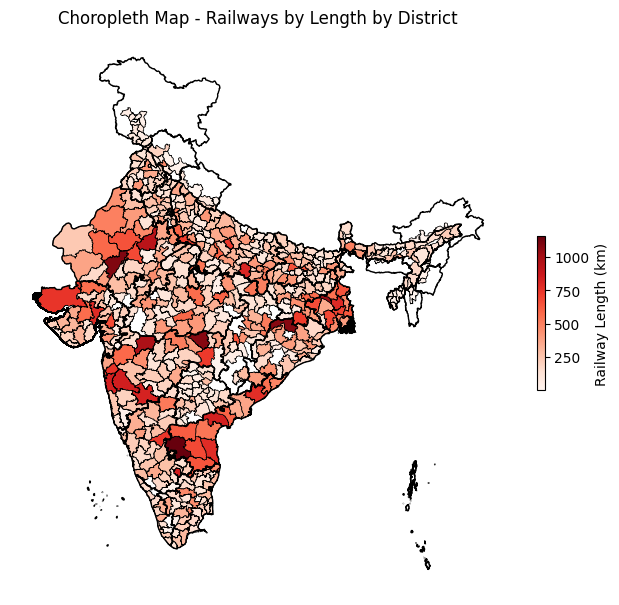

In [ ]:
# Plotting Choropleth Map for Railways Length - A Possible Bad Example for Choropleth Map

fig, ax = plt.subplots(figsize=(8, 10))

gdf_rail.plot(column="rail_km",
         cmap="Reds",
         legend=True,
         edgecolor="black",
         linewidth=0.5,
         ax=ax,
         legend_kwds={
            "shrink": 0.2,          # smaller legend
            "orientation": "vertical",
            "label": "Railway Length (km)"
          }
)

# Plotting the State Boundary (Middle Layer)
print(gdf_rail.crs == gdf_st.crs)
gdf_st = gdf_st.to_crs(gdf_rail.crs)
print(gdf_rail.crs == gdf_st.crs)
gdf_st.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

plt.title("Choropleth Map - Railways by Length by District")
plt.axis("off")
plt.show()

# Geocoding

In [ ]:
# Importing geocoding library
from geopandas.tools import geocode
import pandas as pd

In [ ]:
# Geocoding the districts of India

# Importing the Districts data of India || district_code Source: NHFS (National Family Health Survey)
df2_dc = pd.read_excel("District_Codes.xlsx")
print(df2_dc.head())

# Geocoding the districts
# geo = geocode(
#     df2_dc["district"], provider="nominatim", user_agent="pythongis_book", timeout=10
# )
# geo.head()

     district  district_code
0   ghaziabad            140
1   south goa            586
2      jorhat            312
3  puducherry            635
4       patna            230


In [ ]:
# geo.plot()
# Not all the points have been correctly geocoded

NameError: name 'geo' is not defined

As we can see, not all the points have been correctly geocoded.

In [ ]:
import pandas as pd

# df_excel = gdf.drop(columns="geometry")

gdf.to_excel(
    "/content/india_districts.xlsx",
    index=False
)

# Plotting Areas (Districts) with Treatment

In [ ]:
gdf.head()

,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry
0,Morbi,Gujarat,None,24,673,539476.764723,4.791280e+09,"POLYGON ((7916729.974 2657739.258, 7916794.687..."
1,Ahmadabad,Gujarat,None,24,438,857254.094647,6.966374e+09,"POLYGON ((8011893.249 2638969.809, 8011890.947..."
2,Anand,Gujarat,None,24,440,393046.690523,3.054307e+09,"POLYGON ((8129232.514 2599976.4, 8129320.292 2..."
3,Devbhumi dwarka,Gujarat,None,24,674,661732.986530,4.002784e+09,"MULTIPOLYGON (((7718827.698 2557929.563, 77188..."
4,Jamnagar,Gujarat,None,24,447,737428.071884,5.694271e+09,"MULTIPOLYGON (((7852087.684 2560524.569, 78520..."


In [ ]:
## IHCI Treated Districts in the First Phase | Data Source: National Family Health Survey (NFHS)

# Checking the DISTRICT_L info
# print(gdf["DISTRICT_L"].info())

# Converting the DISTRICT_L datatype to Int
gdf["DISTRICT_L"] = gdf["DISTRICT_L"].astype("Int64")

# Selecting the Phase 1 treated districts
ihci_phase1_treated_dists = gdf.loc[gdf["DISTRICT_L"].isin([28, 32, 33, 37, 662, 423, 396, 399, 565, 566, 567, 557, 471, 494, 495, 498, 508, 688, 689,
                                                            686, 522, 687, 682, 681, 683, 720])]
# print(ihci_phase1_treated_dists.info())

# IHCI Treated States Treated in Phase 1
print("IHCI Treated States in Phase 1:", ihci_phase1_treated_dists["STATE"].unique().tolist())
print("IHCI Treated States Codes in Phase 1:", ihci_phase1_treated_dists["State_LGD"].unique().tolist())

# Printing the first five rows of the IHCI phase 1 treated districts
ihci_phase1_treated_dists.head()

IHCI Treated States in Phase 1: ['Madhya pradesh', 'Kerala', 'Punjab', 'Maharashtra', 'Telangana']
IHCI Treated States Codes in Phase 1: [23, 32, 3, 27, 36]


,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry
66,Bhopal,Madhya pradesh,None,23,396,378109.021909,2.660916e+09,"POLYGON ((8604482.107 2740602.824, 8604511.132..."
89,Chhindwara,Madhya pradesh,None,23,399,814856.774768,1.136809e+10,"POLYGON ((8819916.847 2609624.959, 8819939.069..."
198,Kannur,Kerala,None,32,557,339137.096022,2.976763e+09,"POLYGON ((8401363.232 1379840.917, 8401403.81 ..."
306,Ratlam,Madhya pradesh,None,23,423,559323.236737,4.668624e+09,"POLYGON ((8403447.72 2742124.348, 8403570.672 ..."
360,Thiruvananthapuram,Kerala,None,32,565,284814.505496,2.260982e+09,"POLYGON ((8548173.303 989511.985, 8548234.021 ..."


In [ ]:
# Selecting the Phase 2 treated districts
ihci_phase2_treated_dists = gdf.loc[gdf["DISTRICT_L"].isin([695, 512, 693, 509, 694, 721, 690, 513, 692, 691, 428, 427, 393, 409, 435, 419, 394, 418,
                                                            406, 475, 473, 476, 480, 492, 493, 665, 490, 497, 554, 559, 558, 555, 561, 605, 34, 27,
                                                            30, 42, 306, 307, 317, 318, 313, 308, 314, 309, 664, 311, 600, 532, 546, 552, 551, 226,
                                                            228, 227, 225, 387, 377, 378, 385, 375, 457, 459, 96, 93, 510, 520, 246, 245, 568, 214,
                                                            224, 208, 198, 215, 322, 339, 76, 74, 370, 187, 153, 161, 120])]

# IHCI Treated States Treated in Phase 2
print("IHCI Treated States in Phase 2:", ihci_phase2_treated_dists["STATE"].unique().tolist())
print("IHCI Treated States Codes in Phase 2:", ihci_phase2_treated_dists["State_LGD"].unique().tolist())

# Printing the first five rows of the IHCI phase 2 treated districts
ihci_phase2_treated_dists.head()

IHCI Treated States in Phase 2: ['Gujarat', 'Kerala', 'Madhya pradesh', 'Rajasthan', 'Chhattisgarh', 'Jharkhand', 'Karnataka', 'Sikkim', 'Uttar pradesh', 'Andhra pradesh', 'Goa', 'Puducherry', 'Odisha', 'West bengal', 'Punjab', 'Maharashtra', 'Bihar', 'Telangana', 'Haryana', 'Nagaland', 'Tamil nadu']
IHCI Treated States Codes in Phase 2: [24, 32, 23, 8, 22, 20, 29, 11, 9, 28, 30, 34, 21, 19, 3, 27, 10, 36, 6, 13, 33]


,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry
8,Surat,Gujarat,None,24,459,5.230863e+05,4.175888e+09,"POLYGON ((8133239.935 2459430.7, 8133428.035 2..."
15,Alappuzha,Kerala,None,32,554,2.951378e+05,1.453745e+09,"POLYGON ((8497439.487 1104968.159, 8497577.532..."
53,Barwani,Madhya pradesh,None,23,393,4.937186e+05,5.227384e+09,"POLYGON ((8384539.6 2526616.442, 8384557.428 2..."
60,Betul,Madhya pradesh,None,23,394,7.265026e+05,9.679103e+09,"MULTIPOLYGON (((8571889.645 2472723.093, 85717..."
70,Bikaner,Rajasthan,None,8,93,1.180982e+06,2.924282e+10,"POLYGON ((8242193.581 3376862.21, 8242195.382 ..."


['Andaman_&_nicobar_island', 'Arunanchal_pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadara_&_nagar_havelli', 'Daman_&_diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal_pradesh', 'Jammu_&_kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya_pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Nct_of_delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil_nadu', 'Telangana', 'Tripura', 'Uttar_pradesh', 'Uttarakhand', 'West_bengal', 'Odisha', 'Andhra_pradesh']


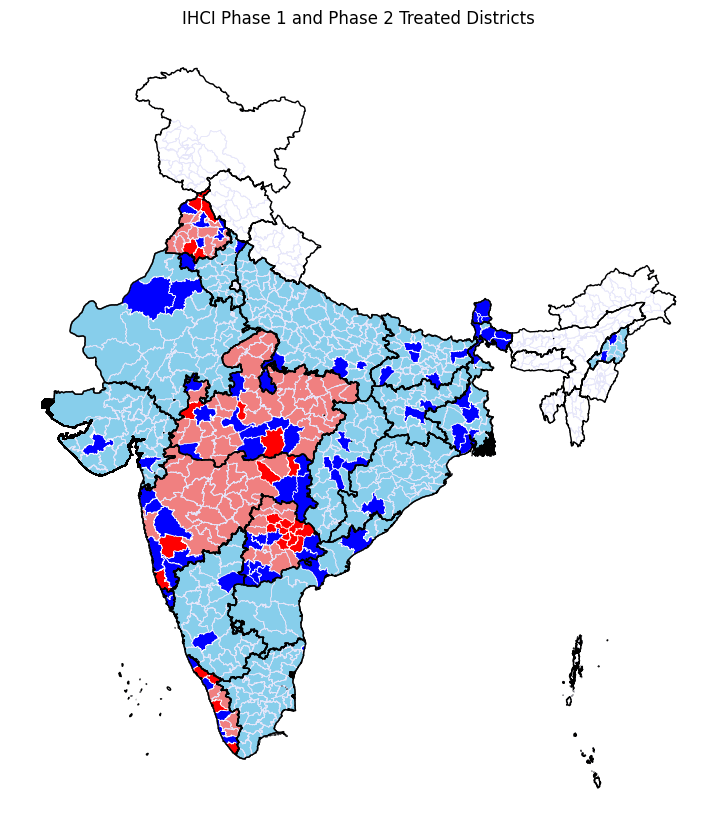

In [ ]:
# Plotting the IHCI Phase I treated districts

# Plotting the Figure
fig, ax = plt.subplots(figsize=(9,12))

# Opening the State Boundary Dataset (Middle Layer)
gdf_st = gpd.read_file("/content/archive_state.zip!Indian_States.shp")
gdf_st = gdf_st.to_crs(gdf.crs)

# Replacing blank spaces ' ' with '_'
gdf_st["st_nm"] = gdf_st["st_nm"].str.replace(' ', '_')

# # IHCI Phase 2 Treated States
ihci_phase1_treated_states = gdf_st.loc[gdf_st["st_nm"].isin(['Punjab', 'Madhya_Pradesh', 'Kerala', 'Maharashtra', 'Telangana'])]

# IHCI Phase 2 Treated States
ihci_phase2_treated_states = gdf_st.loc[gdf_st["st_nm"].isin([
    'Gujarat', 'Kerala', 'Madhya_Pradesh', 'Rajasthan', 'Chhattisgarh',
    'Jharkhand', 'Karnataka', 'Sikkim', 'Uttar_Pradesh', 'Andhra_Pradesh',
    'Goa', 'Puducherry', 'Odisha', 'West_Bengal', 'Punjab', 'Maharashtra',
    'Bihar', 'Telangana', 'Haryana', 'Nagaland', 'Tamil_Nadu'
])]

# Printing the New States List
print(gdf_st["st_nm"].str.capitalize().tolist())

# Plotting the IHCI Phase 2 Treated States (Middle Layer)
ihci_phase2_treated_states.plot(ax=ax, facecolor="skyblue", edgecolor="black", linewidth=1)

# Plotting the IHCI Phase 1 Treated States (Middle Layer)
ihci_phase1_treated_states.plot(ax=ax, facecolor="lightcoral", edgecolor="black", linewidth=1)

# Plotting the Districts Map (Base Layer)
gdf.plot(ax=ax, color="none", edgecolor="lavender", linewidth=0.5)

# Plotting the IHCI Phase 1 Treated Districts (Top Layer)
ihci_phase1_treated_dists.plot(ax=ax, color="red", edgecolor="white", linewidth=0.5)

# Plotting the IHCI Phase 2 Treated Districts (Top Layer)
ihci_phase2_treated_dists.plot(ax=ax, color="blue", edgecolor="white", linewidth=0.5)

# Plotting the State Boundary (Middle Layer)
gdf_st.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

plt.title("IHCI Phase 1 and Phase 2 Treated Districts")
plt.axis("Off")
fig.show()

In [ ]:
gdf_st["st_nm"].str.capitalize().replace({'Andaman & nicobar island': 'Andaman_&_nicobar_island', 'Arunanchal pradesh': 'Arunanchal_pradesh', 'Dadara & nagar havelli': 'Dadara_&_nagar_havelli', 'Daman & diu': 'Daman_&_diu', 'Himachal pradesh': 'Himachal_pradesh', 'Jammu & kashmir': 'Jammu_&_kashmir', 'Madhya pradesh': 'Madhya_pradesh', 'Nct of delhi': 'Nct_of_delhi', 'Tamil nadu': 'Tamil_nadu', 'Uttar pradesh': 'Uttar_pradesh', 'West bengal': 'West_bengal', 'Andhra pradesh': 'Andhra_pradesh'})
print(gdf_st["st_nm"].str.capitalize().tolist())

['Andaman_&_nicobar_island', 'Arunanchal_pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadara_&_nagar_havelli', 'Daman_&_diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal_pradesh', 'Jammu_&_kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya_pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Nct_of_delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil_nadu', 'Telangana', 'Tripura', 'Uttar_pradesh', 'Uttarakhand', 'West_bengal', 'Odisha', 'Andhra_pradesh']


In [ ]:
high_bp = pd.read_excel("High_BP_Over_Years.xlsx")
high_bp["District"] = high_bp["District"].str.lower()
high_bp.head()

,District,Yr_2016,Yr_2019
0,kupwara,0.15,0.24
1,badgam,0.16,0.23
2,leh,0.11,0.19
3,kargil,0.11,0.19
4,punch,0.16,0.20


In [ ]:
high_bp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   District  641 non-null    object 
 1   Yr_2016   641 non-null    float64
 2   Yr_2019   641 non-null    float64
dtypes: float64(2), object(1)
memory usage: 15.2+ KB


In [ ]:
# gdf.columns

In [ ]:
high_bp_dist = high_bp.District.tolist()
gdf_dist = high_bp.District.tolist()
gdf_dist = [each.lower() for each in gdf_dist]
count = 0
for dist in high_bp_dist:
  if dist.lower() in gdf_dist:
    count += 1
  else:
    print(dist)

In [ ]:
count

641

In [ ]:
gdf.head()

,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry
0,Morbi,Gujarat,None,24,673,539476.764723,4.791280e+09,"POLYGON ((7916729.974 2657739.258, 7916794.687..."
1,Ahmadabad,Gujarat,None,24,438,857254.094647,6.966374e+09,"POLYGON ((8011893.249 2638969.809, 8011890.947..."
2,Anand,Gujarat,None,24,440,393046.690523,3.054307e+09,"POLYGON ((8129232.514 2599976.4, 8129320.292 2..."
3,Devbhumi dwarka,Gujarat,None,24,674,661732.986530,4.002784e+09,"MULTIPOLYGON (((7718827.698 2557929.563, 77188..."
4,Jamnagar,Gujarat,None,24,447,737428.071884,5.694271e+09,"MULTIPOLYGON (((7852087.684 2560524.569, 78520..."


In [ ]:
# Merging High BP population data with the Original District shape file dataset
gdf_high_bp = gdf.merge(high_bp, on="District", how="left")

gdf_high_bp.head()

,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry,Yr_2016,Yr_2019
0,Morbi,Gujarat,None,24,673,539476.764723,4.791280e+09,"POLYGON ((7916729.974 2657739.258, 7916794.687...",NaN,NaN
1,Ahmadabad,Gujarat,None,24,438,857254.094647,6.966374e+09,"POLYGON ((8011893.249 2638969.809, 8011890.947...",NaN,NaN
2,Anand,Gujarat,None,24,440,393046.690523,3.054307e+09,"POLYGON ((8129232.514 2599976.4, 8129320.292 2...",NaN,NaN
3,Devbhumi dwarka,Gujarat,None,24,674,661732.986530,4.002784e+09,"MULTIPOLYGON (((7718827.698 2557929.563, 77188...",NaN,NaN
4,Jamnagar,Gujarat,None,24,447,737428.071884,5.694271e+09,"MULTIPOLYGON (((7852087.684 2560524.569, 78520...",NaN,NaN


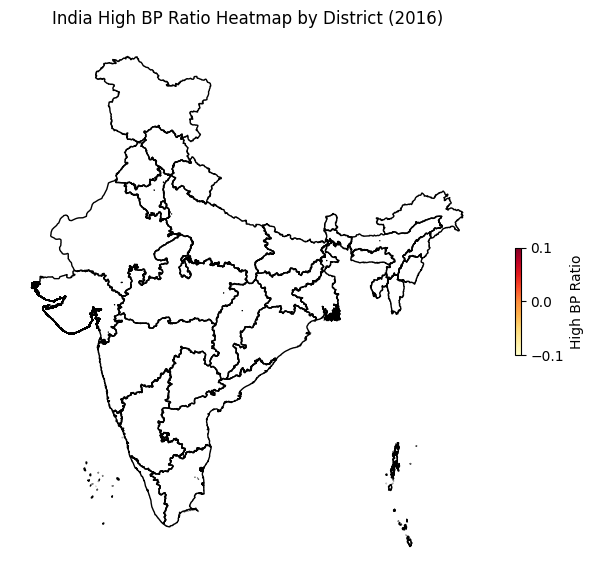

In [ ]:
# Plotting Heatmap for High BP 2016
fig, ax = plt.subplots(figsize=(8, 7))

gdf_high_bp.plot(
    column="Yr_2016",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    legend_kwds={
        "shrink": 0.2,
        "orientation": "vertical",
        "label": "High BP Ratio"
    }
)

# Plotting the State Boundary (Middle Layer)
gdf_st.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

ax.set_title("India High BP Ratio Heatmap by District (2016)")
ax.axis("off")
plt.show()

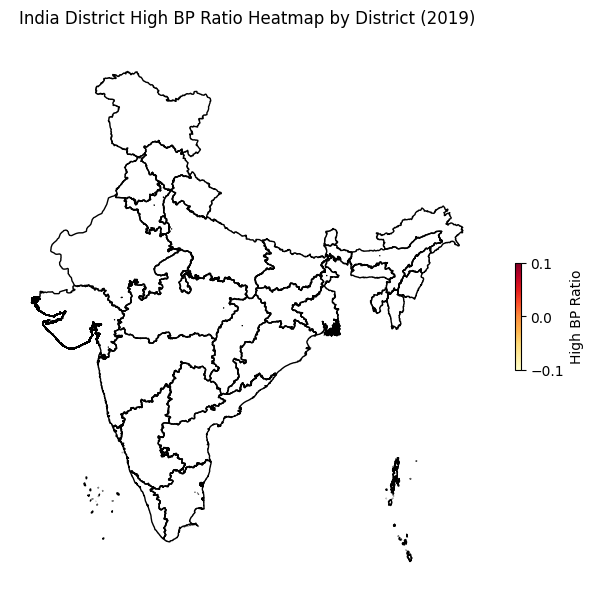

In [ ]:
# Plot heatmap for High BP 2019
fig, ax = plt.subplots(figsize=(8, 7))

gdf_high_bp.plot(
    column="Yr_2019",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    legend_kwds={
        "shrink": 0.2,
        "orientation": "vertical",
        "label": "High BP Ratio"
    }
)

# Plotting the State Boundary (Middle Layer)
gdf_st.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

ax.set_title("India District High BP Ratio Heatmap by District (2019)")
ax.axis("off")
plt.show()

In [ ]:
# Plotting the two figures side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 2016
gdf_high_bp.plot(
    column="Yr_2016",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=axes[0],
    legend_kwds={
        "shrink": 0.3,
        "label": "High BP (%)"
    }
)
gdf_st.plot(ax=axes[0], facecolor="none", edgecolor="black", linewidth=1)
axes[0].set_title("High BP (%) – 2016")
axes[0].axis("off")

# 2019
gdf_high_bp.plot(
    column="Yr_2019",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=axes[1],
    legend_kwds={
        "shrink": 0.3,
        "label": "High BP (%)"
    }
)
gdf_st.plot(ax=axes[1], facecolor="none", edgecolor="black", linewidth=1)
axes[1].set_title("High BP (%) – 2019")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Airports of India

In [ ]:
# Importing the Airports file
df_ap = pd.read_csv("/content/in-airports.csv")
df_ap.head()

In [ ]:
# Plotting the Airports of India

# Dropping the first row to regularise the data format of the rows entry
df_ap = df_ap.iloc[1:].reset_index(drop=True)

# Converting the pandas DataFrame into GeoDataFrame using `geopandas' library
gdf_ap = gpd.GeoDataFrame(
    df_ap,
    geometry=gpd.points_from_xy(df_ap["longitude_deg"], df_ap["latitude_deg"]),
    crs="EPSG:4326"
)

# Plotting the Airports of India
gdf_ap.plot(markersize=3, color="red")
plt.axis("Off")
plt.show()

In [ ]:
# Plotting the Airports of India in state boundaries

# State Shapefile
data = "/content/archive_state.zip"

# Getting names from the ZipFile
with ZipFile(data) as d:
  print(d.namelist())

# Opening the State Boundary Dataset
gdf_st = gpd.read_file("/content/archive_state.zip!Indian_States.shp")

# Checking the geometry datatype
print("State CRS:", gdf_st.crs)
print("Airport CRS:", gdf_ap.crs)
print(gdf.crs == gdf_ap.crs)

# Converting the airport geometry datatype to that of the statefile data
gdf_ap = gdf_ap.to_crs(gdf_st.crs)

# Checking now, if both have the same type of datasets
print(gdf_st.crs == gdf_ap.crs)

# Plotting the Airports of India on the State (Administrative) Map
fig, ax = plt.subplots(figsize=(9,12))

# Base Layer
gdf_st.plot(ax=ax, color="skyblue", edgecolor="white", linewidth=0.7)

# Airports in India
gdf_ap.plot(ax=ax, color="red", alpha=0.6)
plt.axis("Off")
plt.show()
# gdf.head()

# Time Use Survey

In [ ]:
df_tus = pd.read_stata("/content/tus106HH.dta")
df_tus.head()

In [ ]:
df_tus.columns

In [ ]:
import geopandas as gpd

# List available layers first
import fiona

layers = fiona.listlayers("/content/GHS_UCDB_REGION_CENTRAL_AND_SOUTHERN_ASIA_R2024A.gpkg")
# print(layers)

# Read a specific layer
# gdf = gpd.read_file("/content/GHS_UCDB_REGION_CENTRAL_AND_SOUTHERN_ASIA_R2024A.gpkg", layer="your_layer_name")

# Or just read the first/default layer
gdf = gpd.read_file("/content/GHS_UCDB_REGION_CENTRAL_AND_SOUTHERN_ASIA_R2024A.gpkg")

# print(gdf.head())
print(gdf.crs)  # Check the coordinate reference system
gdf.head()
layers

PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","54009"]]


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'GHS_UCDB_REGION_CENTRAL_AND_SOUTHERN_ASIA_R2024A.gpkg': 'GHSL_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A' (default), 'GHSL_UCDB_THEME_GHSL_GLOBE_R2024A', 'GHSL_UCDB_THEME_CLIMATE_GLOBE_R2024A', 'GHSL_UCDB_THEME_EMISSIONS_GLOBE_R2024A', 'GHSL_UCDB_THEME_EXPOSURE_GLOBE_R2024A', 'GHSL_UCDB_THEME_GEOGRAPHY_GLOBE_R2024A', 'GHSL_UCDB_THEME_GREENNESS_GLOBE_R2024A', 'GHSL_UCDB_THEME_HAZARD_RISK_GLOBE_R2024A', 'GHSL_UCDB_THEME_HEALTH_GLOBE_R2024A', 'GHSL_UCDB_THEME_INFRASTRUCTURES_GLOBE_R2024A', 'GHSL_UCDB_THEME_LULC_GLOBE_R2024A', 'GHSL_UCDB_THEME_NATURAL_SYSTEMS_GLOBE_R2024A', 'GHSL_UCDB_THEME_SDG_GLOBE_R2024A', 'GHSL_UCDB_THEME_SOCIOECONOMIC_GLOBE_R2024A', 'GHSL_UCDB_THEME_WATER_GLOBE_R2024A', 'UC_centroids'. Specify layer parameter to avoid this warning.
  result = read_func(


['GHSL_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A',
 'GHSL_UCDB_THEME_GHSL_GLOBE_R2024A',
 'GHSL_UCDB_THEME_CLIMATE_GLOBE_R2024A',
 'GHSL_UCDB_THEME_EMISSIONS_GLOBE_R2024A',
 'GHSL_UCDB_THEME_EXPOSURE_GLOBE_R2024A',
 'GHSL_UCDB_THEME_GEOGRAPHY_GLOBE_R2024A',
 'GHSL_UCDB_THEME_GREENNESS_GLOBE_R2024A',
 'GHSL_UCDB_THEME_HAZARD_RISK_GLOBE_R2024A',
 'GHSL_UCDB_THEME_HEALTH_GLOBE_R2024A',
 'GHSL_UCDB_THEME_INFRASTRUCTURES_GLOBE_R2024A',
 'GHSL_UCDB_THEME_LULC_GLOBE_R2024A',
 'GHSL_UCDB_THEME_NATURAL_SYSTEMS_GLOBE_R2024A',
 'GHSL_UCDB_THEME_SDG_GLOBE_R2024A',
 'GHSL_UCDB_THEME_SOCIOECONOMIC_GLOBE_R2024A',
 'GHSL_UCDB_THEME_WATER_GLOBE_R2024A',
 'UC_centroids']

In [ ]:
import rasterio

with rasterio.open("/content/GHS_WUP_BUILT_S_E2025_GLOBE_R2025A_54009_1000_V1_0.tif") as src:
    data = src.read()          # Read all bands as numpy array
    band1 = src.read(1)        # Read a single band
    print(src.crs)             # Coordinate reference system
    print(src.transform)       # Affine transform
    print(src.meta)            # Metadata

RasterioIOError: Read failed. See previous exception for details.

In [ ]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

# Open the file
with rasterio.open("/content/GHS_WUP_BUILT_S_E2025_GLOBE_R2025A_54009_1000_V1_0.tif") as src:
    print(src.meta)          # Metadata
    print(src.crs)           # CRS
    print(src.count)         # Number of bands
    data = src.read()        # All bands (shape: bands, rows, cols)

    # --- Option 1: Quick plot with rasterio's built-in show ---
    show(src, title="My GeoTIFF")

    # --- Option 2: Single band (e.g. DEM or grayscale) ---
    band1 = src.read(1)
    plt.figure(figsize=(10, 8))
    plt.imshow(band1, cmap="terrain")
    plt.colorbar(label="Value")
    plt.title("Band 1")
    plt.show()

    # --- Option 3: RGB composite (if 3+ bands) ---
    if src.count >= 3:
        rgb = np.dstack([src.read(1), src.read(2), src.read(3)])
        # Normalize to 0-255 for display
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
        plt.figure(figsize=(10, 8))
        plt.imshow(rgb)
        plt.title("RGB Composite")
        plt.show()

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -200.0, 'width': 36082, 'height': 18000, 'count': 1, 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(1000.0, 0.0, -18041000.0,
       0.0, -1000.0, 9000000.0)}
ESRI:54009
1


RasterioIOError: Read failed. See previous exception for details.

In [ ]:
import os
print(f"File size: {os.path.getsize('/content/GHS_WUP_BUILT_S_E2025_GLOBE_R2025A_54009_1000_V1_0.tif') / 1e9:.2f} GB")

File size: 0.17 GB


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -200.0, 'width': 36082, 'height': 18000, 'count': 1, 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(1000.0, 0.0, -18041000.0,
       0.0, -1000.0, 9000000.0)}
Image size: 36082 x 18000


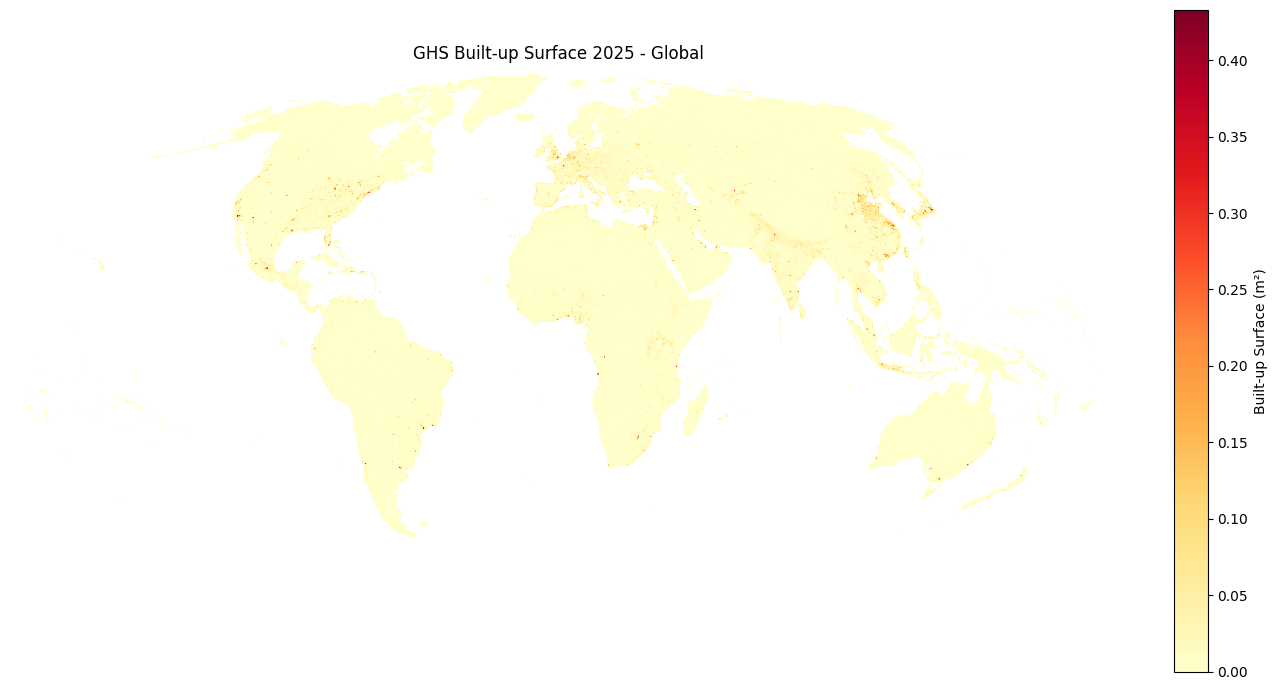

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from rasterio.enums import Resampling

with rasterio.open("/content/GHS_WUP_BUILT_S_E2025_GLOBE_R2025A_54009_1000_V1_0.tif") as src:
    print(src.meta)
    print(f"Image size: {src.width} x {src.height}")

    # Downsample to a manageable size for visualization (1/20th of original)
    scale_factor = 0.05
    out_width = int(src.width * scale_factor)
    out_height = int(src.height * scale_factor)

    # Read downsampled data
    data = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average
    )

    # Mask nodata values
    nodata = src.nodata  # -200.0
    data = np.where(data == nodata, np.nan, data)

    # Plot
    plt.figure(figsize=(14, 7))
    plt.imshow(
        data,
        cmap="YlOrRd",
        interpolation="none"
    )
    plt.colorbar(label="Built-up Surface (m²)")
    plt.title("GHS Built-up Surface 2025 - Global")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.4028230607370965e+38, 'width': 43201, 'height': 21600, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0083333333333, 0.0, -180.0,
       0.0, -0.0083333333333, 89.99999999928002)}
Image size: 43201 x 21600


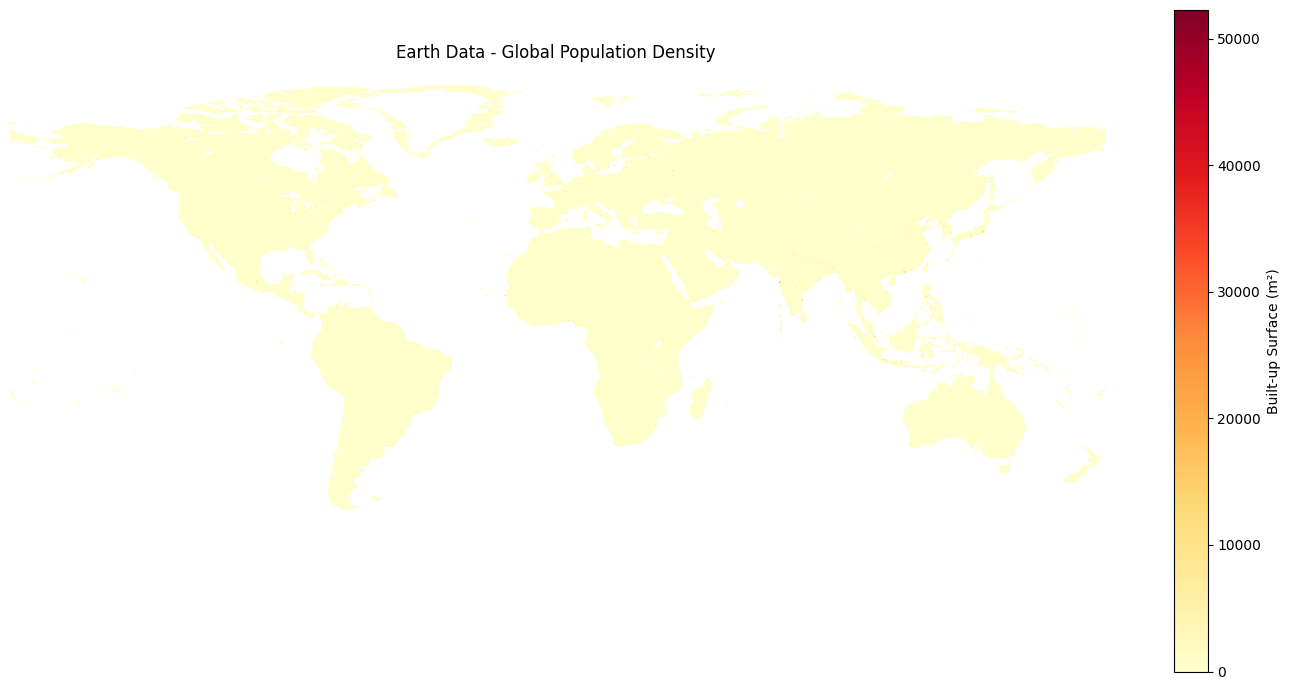

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from rasterio.enums import Resampling

with rasterio.open("/content/popdynamics-global-pop-density-time-series-estimates_2000.tif") as src:
    print(src.meta)
    print(f"Image size: {src.width} x {src.height}")

    # Downsample to a manageable size for visualization (1/20th of original)
    scale_factor = 0.05
    out_width = int(src.width * scale_factor)
    out_height = int(src.height * scale_factor)

    # Read downsampled data
    data = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average
    )

    # Mask nodata values
    nodata = src.nodata  # -200.0
    data = np.where(data == nodata, np.nan, data)

    # Plot
    plt.figure(figsize=(14, 7))
    plt.imshow(
        data,
        cmap="YlOrRd",
        interpolation="none"
    )
    plt.colorbar(label="Built-up Surface (m²)")
    plt.title("Earth Data - Global Population Density ")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

file_path = "/content/part-00080-4feead82-d499-422b-94cb-c036c212127a.c000.csv"
df_buildings = pd.read_csv(file_path)
df_buildings.head()

# # If there's a geometry column (WKT format)
# # Replace 'geometry' with your actual geometry column name
# df_buildings['geometry'] = df_buildings['geometry'].apply(wkt.loads)
# gdf = gpd.GeoDataFrame(df_buildings, geometry='geometry', crs="EPSG:4326")

# # Plot
# fig, ax = plt.subplots(figsize=(12, 10))
# gdf.plot(ax=ax, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.7)
# plt.title("Buildings")
# plt.axis("off")
# plt.tight_layout()
# plt.show()
# # df_buidings.head()

/tmp/ipython-input-480/2569483415.py:7: DtypeWarning: Columns (62,63,64,65,66,67,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_buildings = pd.read_csv(file_path)


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69
0,"{""type"": ""Feature""","""properties"": { ""height"": -1.0","""confidence"": -1.0}","geometry: {""type"": ""Polygon""",coordinates: [[[83.36796122185994,18.14153360765478],[83.36801754344218,18.141534102117575],[83.36801650278585,18.141641145788057],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"{""type"": ""Feature""","""properties"": { ""height"": -1.0","""confidence"": -1.0}","geometry: {""type"": ""Polygon""",coordinates: [[[83.37009775776126,18.115899182359087],[83.37009982070008,18.116021514917207],[83.37001669357417,18.116022781187453],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"{""type"": ""Feature""","""properties"": { ""height"": -1.0","""confidence"": -1.0}","geometry: {""type"": ""Polygon""",coordinates: [[[83.37059066448022,18.13894723507653],[83.37050761608178,18.138949974784026],[83.37050343111208,18.138835411639946],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"{""type"": ""Feature""","""properties"": { ""height"": -1.0","""confidence"": -1.0}","geometry: {""type"": ""Polygon""",coordinates: [[[83.37110996250388,18.119178937411803],[83.37111151548395,18.119209456461306],[83.37100715342567,18.11921425336419],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"{""type"": ""Feature""","""properties"": { ""height"": -1.0","""confidence"": -1.0}","geometry: {""type"": ""Polygon""",coordinates: [[[83.37136209311343,18.117789233329134],[83.37138896807129,18.117927263118418],[83.3712826386103,18.11794596384452],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiPolygon
import json
import geopandas as gpd

# Read all lines and parse as individual GeoJSON features
with open("/content/part-00146-4feead82-d499-422b-94cb-c036c212127a.c000.csv", "r") as f:
    features = [json.loads(line) for line in f if line.strip()]

# Wrap into a FeatureCollection
feature_collection = {
    "type": "FeatureCollection",
    "features": features
}

# Load into GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(feature_collection)
print(gdf.head())
print(f"Total polygons: {len(gdf)}")

                                            geometry  height  confidence
0  POLYGON ((73.45133 36.62327, 73.45132 36.62341...    -1.0        -1.0
1  POLYGON ((73.7604 36.70095, 73.76047 36.70095,...    -1.0        -1.0
2  POLYGON ((73.81212 36.67026, 73.81219 36.67025...    -1.0        -1.0
3  POLYGON ((73.41568 36.65412, 73.41569 36.65406...    -1.0        -1.0
4  POLYGON ((73.42017 36.65198, 73.42018 36.65196...    -1.0        -1.0
Total polygons: 715


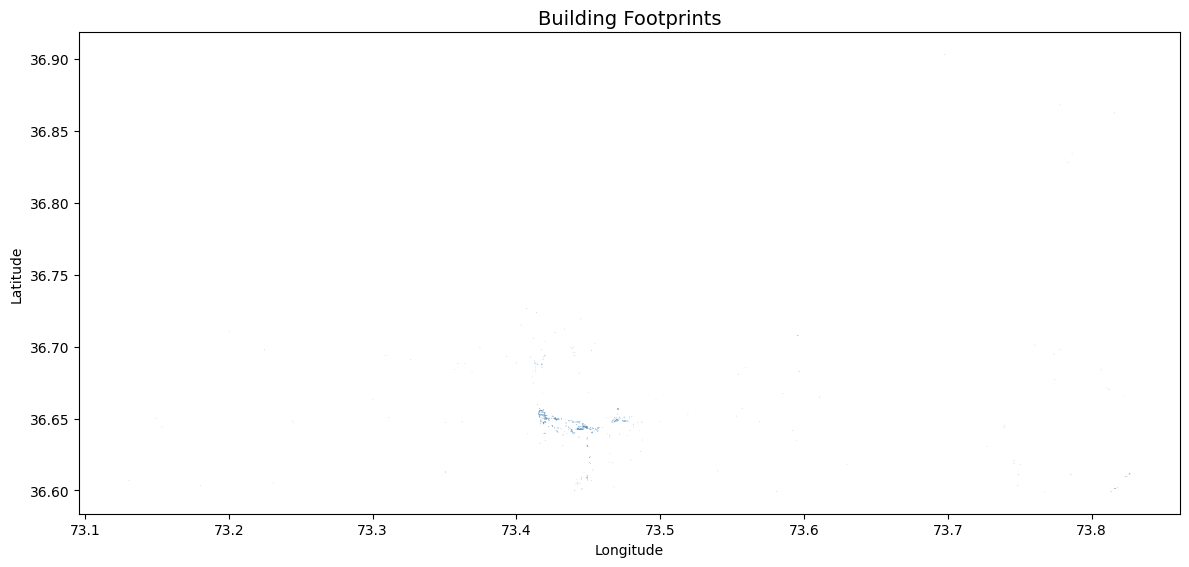

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    edgecolor="steelblue",
    facecolor="lightblue",
    linewidth=0.5,
    alpha=0.7
)

ax.set_title("Building Footprints", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

Polygons in region: 628


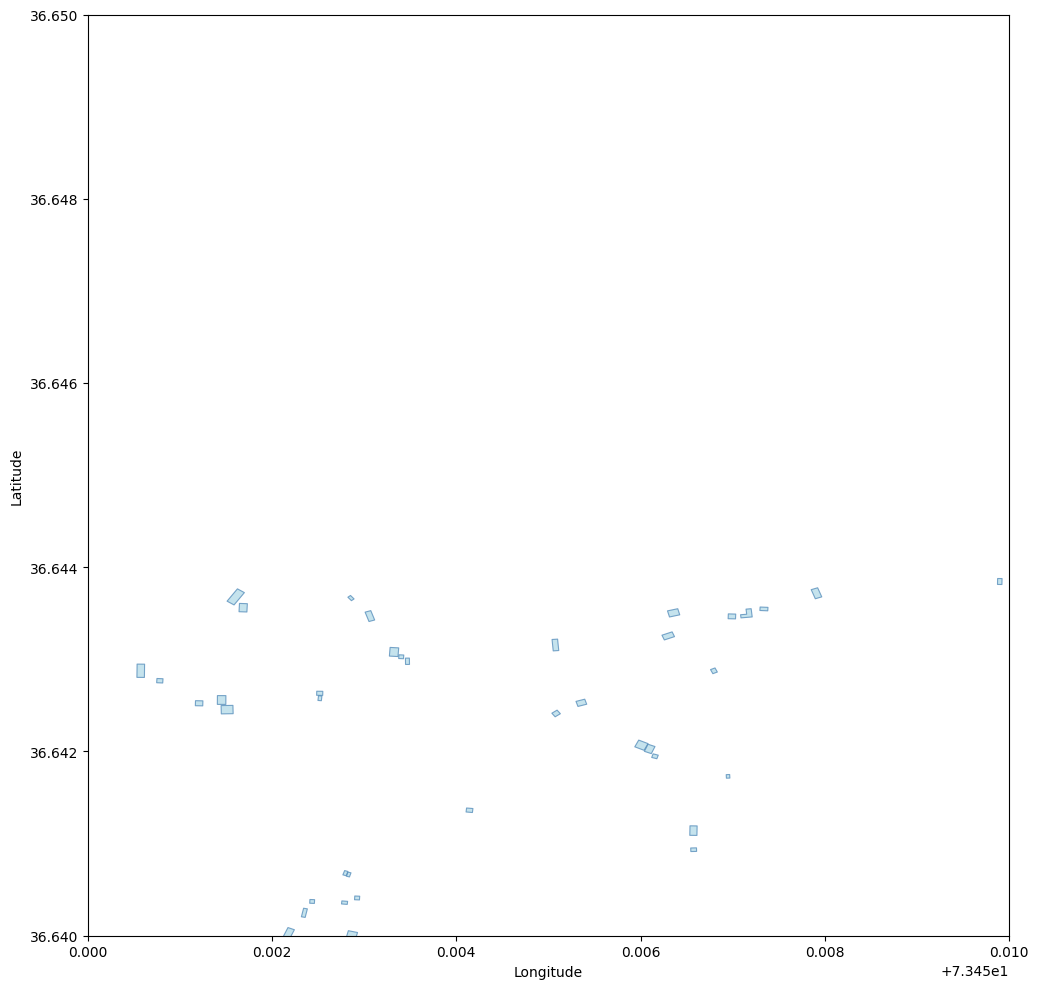

In [ ]:
import json
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

# Load the file
with open("/content/part-00146-4feead82-d499-422b-94cb-c036c212127a.c000.csv", "r") as f:
    features = [json.loads(line) for line in f if line.strip()]

# Wrap into a FeatureCollection and load into GeoDataFrame
gdf = gpd.GeoDataFrame.from_features({
    "type": "FeatureCollection",
    "features": features
})

# Define bounding box: (min_lon, min_lat, max_lon, max_lat)
bbox = box(73.4, 36.60, 73.5, 36.70)

# Filter rows where geometry is within (or intersects) the bounding box
gdf_filtered = gdf[gdf.geometry.intersects(bbox)].copy()
print(f"Polygons in region: {len(gdf_filtered)}")

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

gdf_filtered.plot(
    ax=ax,
    edgecolor="steelblue",
    facecolor="lightblue",
    linewidth=0.8,
    alpha=0.7
)

# Set axis limits to your exact bounds
ax.set_xlim(73.45, 73.46)
ax.set_ylim(36.64, 36.65)

# ax.set_title("Building Footprints (Lon: 73.4–73.5, Lat: 36.60–36.70)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()